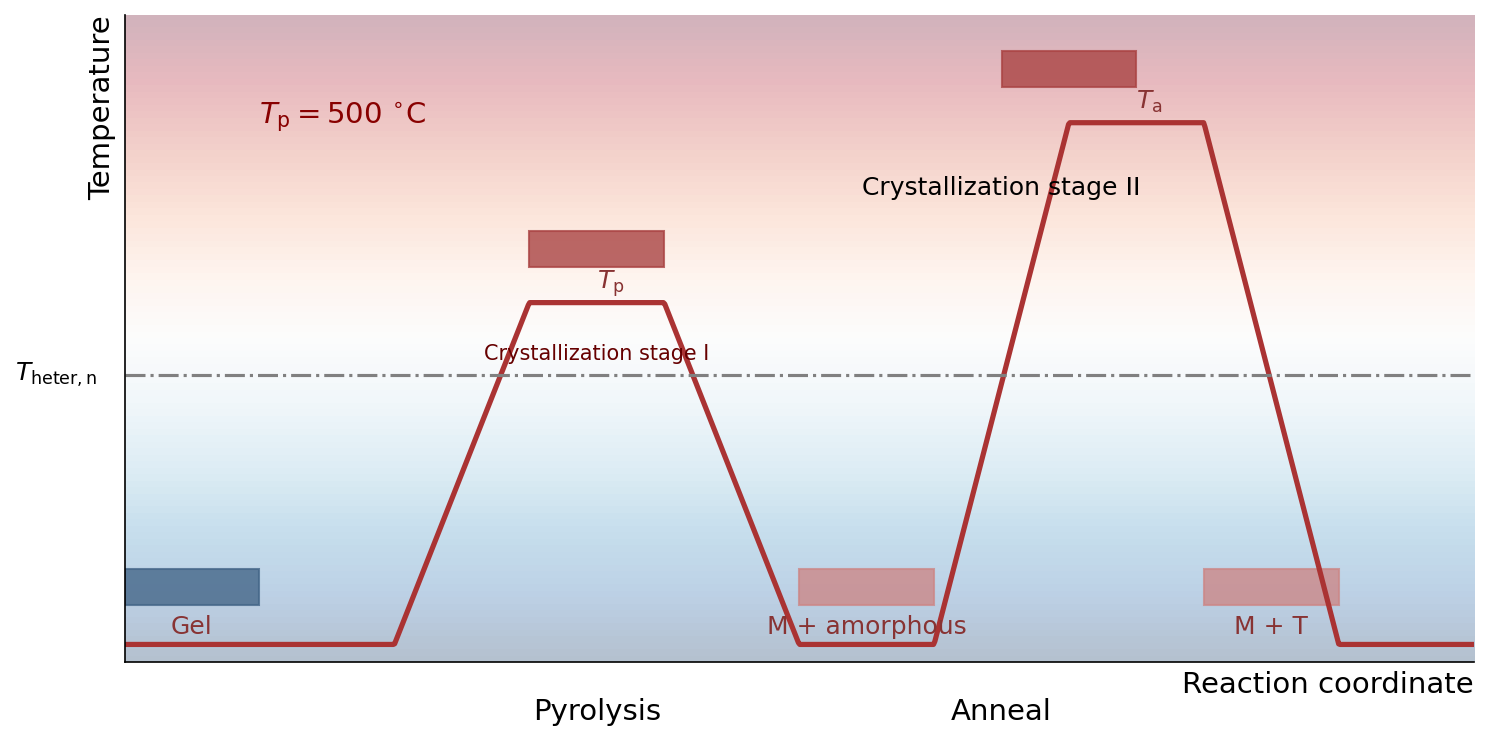

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data Simulation ---
# Reaction Coordinate (Time)
time = np.linspace(0, 100, 1000)

# Temperature Profile
# 1. Gel (Low)
# 2. Pyrolysis (Ramp -> Hold Tp -> Cool)
# 3. Anneal (Ramp -> Hold Ta -> Cool)
temp = np.zeros_like(time)
# Base
temp[:] = 25 
# Pyrolysis: Start t=20, Ramp to 30, Hold to 40, Cool to 50
mask_pyro_ramp = (time >= 20) & (time < 30)
temp[mask_pyro_ramp] = 25 + (500 - 25) * (time[mask_pyro_ramp] - 20) / 10
mask_pyro_hold = (time >= 30) & (time < 40)
temp[mask_pyro_hold] = 500
mask_pyro_cool = (time >= 40) & (time < 50)
temp[mask_pyro_cool] = 500 - (500 - 25) * (time[mask_pyro_cool] - 40) / 10

# Anneal: Start t=60, Ramp to 70, Hold to 80, Cool to 90
mask_ann_ramp = (time >= 60) & (time < 70)
temp[mask_ann_ramp] = 25 + (750 - 25) * (time[mask_ann_ramp] - 60) / 10
mask_ann_hold = (time >= 70) & (time < 80)
temp[mask_ann_hold] = 750
mask_ann_cool = (time >= 80) & (time < 90)
temp[mask_ann_cool] = 750 - (750 - 25) * (time[mask_ann_cool] - 80) / 10


# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

# Background Gradient
gradient = np.linspace(0, 1, 100)
X, Y = np.meshgrid([0, 100], np.linspace(0, 900, 100))
Z = Y 
ax.imshow(Z, extent=[0, 100, 0, 900], aspect='auto', cmap='RdBu_r', alpha=0.3, origin='lower')

# Temperature Line
ax.plot(time, temp, color='#AA3333', linewidth=2.5)

# Labels and Text
ax.text(5, 40, 'Gel', color='#883333', ha='center', fontsize=12)
ax.text(35, 520, r'$T_{\mathrm{p}}$', color='#883333', fontsize=12)
ax.text(35, 420, 'Crystallization stage I', color='#660000', ha='center', fontsize=10)
ax.text(75, 770, r'$T_{\mathrm{a}}$', color='#883333', fontsize=12)
ax.text(65, 650, 'Crystallization stage II', color='black', ha='center', fontsize=12)
ax.text(10, 750, r'$T_{\mathrm{p}} = 500\ ^{\circ}$C', color='#880000', fontsize=14)

# Phase labels
ax.text(55, 40, 'M + amorphous', color='#883333', ha='center', fontsize=12)
ax.text(85, 40, 'M + T', color='#883333', ha='center', fontsize=12)

# Horizontal dashed line (Theter,n)
ax.axhline(400, color='gray', linestyle='-.')
ax.text(-2, 400, r'$T_{\mathrm{heter,n}}$', va='center', ha='right', fontsize=12)

# X Axis labels
ax.text(35, -80, 'Pyrolysis', ha='center', fontsize=14)
ax.text(65, -80, 'Anneal', ha='center', fontsize=14)
ax.set_xlabel('Reaction coordinate', loc='right', fontsize=14)
ax.set_xticks([])

# Y Axis
ax.set_ylabel('Temperature', loc='top', fontsize=14)
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Placeholders for Schematic Blocks
# Just drawing simple rectangles to indicate where they would be
# Gel
rect1 = plt.Rectangle((0, 80), 10, 50, color='#446688', alpha=0.8)
ax.add_patch(rect1)
# Pyro
rect2 = plt.Rectangle((30, 550), 10, 50, color='#aa4444', alpha=0.8)
ax.add_patch(rect2)
# M+Amorph
rect3 = plt.Rectangle((50, 80), 10, 50, color='#cc8888', alpha=0.8)
ax.add_patch(rect3)
# CI + CII
rect4 = plt.Rectangle((65, 800), 10, 50, color='#aa4444', alpha=0.8)
ax.add_patch(rect4)
# M+T
rect5 = plt.Rectangle((80, 80), 10, 50, color='#cc8888', alpha=0.8)
ax.add_patch(rect5)

plt.tight_layout()
plt.show()
